In [19]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [20]:
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [21]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
sentences = [
    # Cricket
    "Cricket is one of the most popular sports in the world, especially in countries like India, Australia and England.",
    "India won its first ICC Cricket World Cup in 1983.",
    "Abhishek Sharma plays for SRH in IPL tournament.",
    "Virat Kohli is one of the greatest batsmen India has ever seen.",

    # Travel
    "Travel allows us to step outside our daily routines and experience life in new ways.",
    "By visiting different places, we learn about traditions, languages, cuisines and lifestyles that are different from our own.",
    "Travel also contributes to personal growth. It teaches independence and adaptability.",

    # MBA
    "An MBA is a postgraduate degree focused on business management and leadership skills.",
    "MBA programs help students develop decision-making, problem-solving, and strategic thinking abilities.",
    "Many students pursue an MBA to advance their careers or move into leadership roles."
]

In [23]:
embeddings = model.encode(sentences)

In [24]:
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

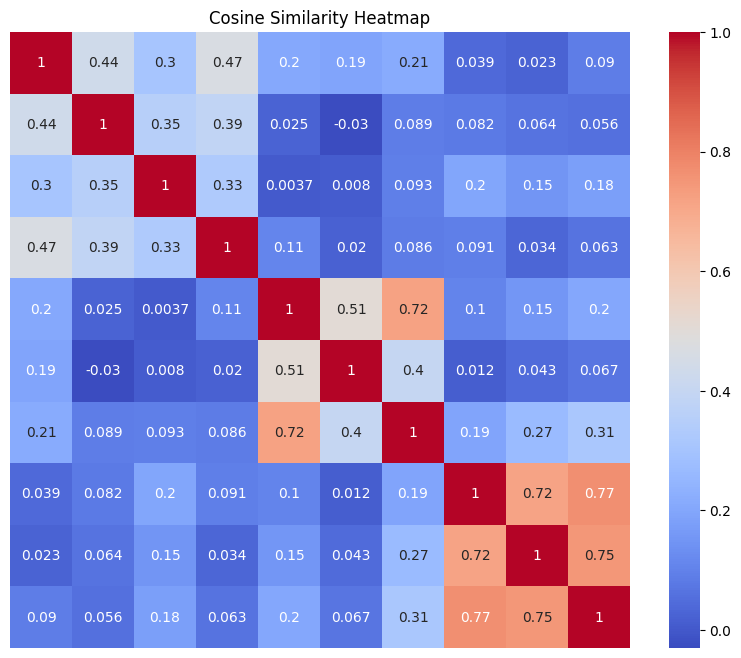

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Cosine Similarity Heatmap")
plt.show()

In [27]:
query = "Indians are obsessed with cricket."
query_embedding = model.encode(query)

In [28]:
hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

In [33]:
print("Query:", query)
print("\nTop 2 similar sentences:\n")
for hit in hits:
    print(f"Sentence: {sentences[hit['corpus_id']]}")
    print(f"Similarity Score: {hit['score']:.4f}\n")

Query: Indians are obsessed with cricket.

Top 2 similar sentences:

Sentence: Cricket is one of the most popular sports in the world, especially in countries like India, Australia and England.
Similarity Score: 0.6228

Sentence: India won its first ICC Cricket World Cup in 1983.
Similarity Score: 0.4484

